### sign issue
- I went back to using `np.sign()` to pick the sign. I have my own sign picker function that should do the same thing, but it doesn't work when I use my function.
- If I use `np.sign()`, it works everywhere except `y=0`.


Evaluating z at index (2, 0) and coordinates (-95.96, -100.00)
sign of partialx = -1


Evaluating z at index (4, 0) and coordinates (-91.92, -100.00)
sign of partialx = -1


Evaluating z at index (6, 0) and coordinates (-87.88, -100.00)
sign of partialx = -1


Evaluating z at index (8, 0) and coordinates (-83.84, -100.00)
sign of partialx = -1


Evaluating z at index (10, 0) and coordinates (-79.80, -100.00)
sign of partialx = -1


Evaluating z at index (12, 0) and coordinates (-75.76, -100.00)
sign of partialx = -1


Evaluating z at index (14, 0) and coordinates (-71.72, -100.00)
sign of partialx = -1


Evaluating z at index (16, 0) and coordinates (-67.68, -100.00)
sign of partialx = -1


Evaluating z at index (18, 0) and coordinates (-63.64, -100.00)
sign of partialx = -1


Evaluating z at index (20, 0) and coordinates (-59.60, -100.00)
sign of partialx = -1


Evaluating z at index (22, 0) and coordinates (-55.56, -100.00)
sign of partialx = -1


Evaluating z at index (24, 0) and c

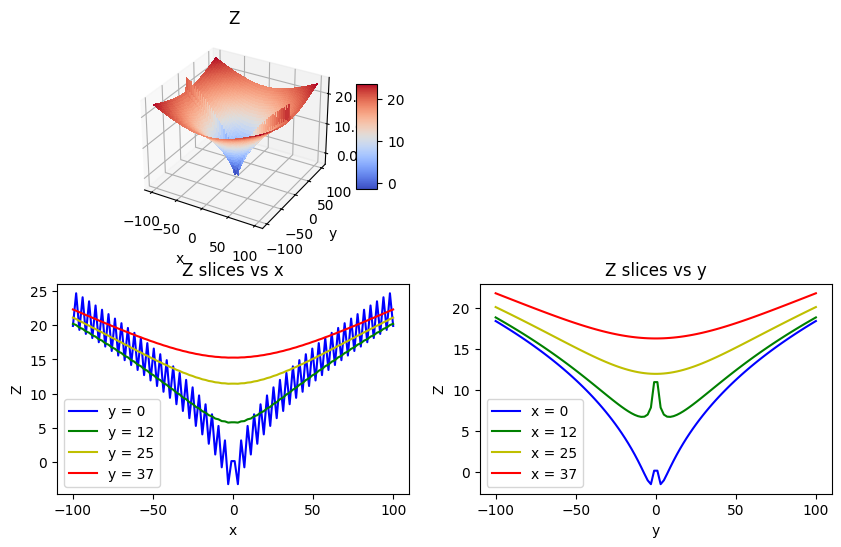

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

'''
Evaluate z by taking advantage of discretized grid rather than integration.

Linearized Schwarzchild metric with Single BH at the center
'''

# =========================
# Spacetime Metric
# ========================
# Linearized Schwarzschild
def g_xx(x, y):
    d = np.sqrt(x**2 + y**2)
    return 1 + 2*GM * (x**2 / d**3)
def g_xy(x, y):
    d = np.sqrt(x**2 + y**2)
    return 2*GM * (x*y / d**3)
def g_yy(x, y):
    d = np.sqrt(x**2 + y**2)
    return 1 + 2*GM * (y**2 / d**3)

# =========================
# Embedding PDE
# =========================
# sign picker
def pick_partialx_sign(x, y):
    sign = None
    if x >= 0:
        sign = 1
    elif x < 0:
        sign = -1
    return sign
# Embedding PDE
def partial_x_Z(x, y):
    return np.sqrt(g_xx(x, y) - 1)
def partial_y_Z(x, y):
    return np.sqrt(g_yy(x, y) - 1)

# ========================
# values for the system
# ========================
GM = 1
n_steps = 100 # must be even 

# ========================
# Discretize the metric
# ========================
# values
x_start, x_end = -100, 100
y_start, y_end = -100, 100
dx = (x_end - x_start) / (n_steps - 1)
dy = (y_end - y_start) / (n_steps - 1)
# create the grid
x_axis = np.linspace(x_start, x_end, n_steps)
y_axis = np.linspace(y_start, y_end, n_steps)
x_meshed, y_meshed = np.meshgrid(x_axis, y_axis)
r = np.sqrt(x_meshed**2 + y_meshed**2)
# discretize the metric
g_xx_discretized = g_xx(x_meshed, y_meshed)
g_xy_discretized = g_xy(x_meshed, y_meshed)
g_yy_discretized = g_yy(x_meshed, y_meshed)

# ========================
# Evaluate Z(x,y)
# ========================
# initialize Z
z = np.zeros_like(x_meshed)
# evaluate the boundary condition
left_boundary = 2 * np.sqrt(r[0] - GM)
right_boundary = 2 * np.sqrt(r[-1] - GM)
# apply the boundary conditions
z[:, 0] = left_boundary    # for odd  points
z[:, -1] = right_boundary  # for even points
# evaluate z(x,y)
for j in range(n_steps): 
    y = y_start + j*dy
    for i in range(2, n_steps, 2): # even indeces
        x = x_start + i*dx
        print(f'\nEvaluating z at index ({i}, {j}) and coordinates ({x:.2f}, {y:.2f})')
        sign_partialx = pick_partialx_sign(x, y)
        print(f'sign of partialx = {sign_partialx}\n')
        z[j][i] = 2*dx * np.sign(x)*np.sqrt(g_xx_discretized[j][i-1] - 1) + z[j][i-2]
    for i in range(n_steps-3, 0, -2): # odd indeces
        x = x_end - i*dx
        print(f'\nEvaluating z at index ({i}, {j}) and coordinates ({x:.2f}, {y:.2f})\n')
        sign_partialx = pick_partialx_sign(x, y)
        print(f'sign of partialx = {sign_partialx}\n')
        z[j][i] = 2*dx * np.sign(x)*np.sqrt(g_xx_discretized[j][i+1] - 1) + z[j][i+2]


# ========================
# Plots
# ========================
# the function
def plot_3d_and_slice(surface, surface_name):
    num_slices = 4

    fig= plt.figure(figsize=(10, 6))
    ax_3d = fig.add_subplot(221, projection='3d')
    ax_slicex = fig.add_subplot(223)
    ax_slicey = fig.add_subplot(224)

    # from matplotlib example (modified)
    surf = ax_3d.plot_surface(x_meshed, y_meshed, surface, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    ax_3d.zaxis.set_major_formatter('{x:.02f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    ax_3d.set(xlabel='x', ylabel='y', title=surface_name)
    # ax_3d.set_zlim(bottom=0)

    color = ['b', 'g', 'y' , 'r']
    while len(color) < num_slices:
        color.append['r']
    
    for i in range(num_slices):
         ax_slicex.plot(x_axis, surface[int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'y = {int(100*i/2/num_slices)}')
         ax_slicex.set(xlabel='x', ylabel=surface_name, title=f'{surface_name} slices vs x')
         ax_slicey.plot(y_axis, surface[:,int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'x = {int(100*i/2/num_slices)}')
         ax_slicey.set(xlabel='y', ylabel=surface_name, title=f'{surface_name} slices vs y')
    ax_slicex.legend()
    ax_slicey.legend()
    
    plt.tight_layout
    plt.show()
    return None
'''
# plot the metric
plot_3d_and_slice(g_xx_discretized, '$g_{xx}$')
plot_3d_and_slice(g_xy_discretized, '$g_{xy}$')
plot_3d_and_slice(g_yy_discretized, '$g_{yy}$')
'''
# plot Z
plot_3d_and_slice(z, 'Z')

In [ ]:
### Value Checks
''' CHECK COMPLETE
# r
plot_3d_and_slice(r, 'r')

# boundary conditions
print(left_boundary)
print(right_boundary)
fig, ax = plt.subplots()
ax.plot(x_axis, z[:,0], 'r', label='left boundary')
ax.plot(x_axis, z[:,-1], 'b--', label='right boundary')
ax.set(ylim=(0,25))
ax.legend()

# shape of z
print(f'\nz.shape = {z.shape}\n')

# values around the boundaries
print(f'z[:10, 0] = {z[:10, 0]}')
print(f'z[:10, 1] = {z[:10, 1]}')
print(f'z[:10, 2] = {z[:10, 2]}')
print(f'z[:10, 3] = {z[:10, 3]}')
print()
print(f'z[:10, -4] = {z[:10, -4]}')
print(f'z[:10, -3] = {z[:10, -3]}')
print(f'z[:10, -2] = {z[:10, -2]}')
print(f'z[:10, -1] = {z[:10, -1]}')
print()
print(f'z[0, :10] = {z[0, :10]}')
print(f'z[1, :10] = {z[1, :10]}')
print(f'z[2, :10] = {z[2, :10]}')
print(f'z[3, :10] = {z[3, :10]}')
print()
print(f'z[-4, :10] = {z[-4, :10]}')
print(f'z[-3, :10] = {z[-3, :10]}')
print(f'z[-2, :10] = {z[-2, :10]}')
print(f'z[-1, :10] = {z[-1, :10]}')
'''

z[:10, 0] = [23.69990348 23.29221433 22.89357068 22.50624773 22.13283645 21.77625143
 21.43972228 21.12676206 20.84110566 20.5866126 ]
z[:10, 1] = [13.56938713 12.35558982 11.05158538 12.32924042 10.9515882  12.40422801
 14.02441843 12.60515626 10.96108489 12.95061526]
z[:10, 2] = [24.8370463  24.49426178 21.62292122 21.16354685 20.71508416 20.28115267
 19.865997   19.47450174 19.11215539 18.7849413 ]
z[:10, 3] = [14.67783563 13.5321171  12.30078973 13.65560111 12.35924925 13.8967073
 15.60423386 14.27337042 12.71678616 14.79037825]

z[:10, -4] = [32.72197133 33.05231156 30.94505271 31.35689435 29.12635819 29.65579555
 27.2752107  27.98015369 25.40193898 26.38284695]
z[:10, -3] = [22.56276066 22.09016688 21.62292122 23.84894861 23.55058874 23.27135018
 23.01344756 22.77902238 22.57005593 22.3882839 ]
z[:10, -2] = [33.83041983 34.22883884 32.19425706 32.68325504 30.53401925 31.14827484
 28.85502613 29.64836785 27.15764025 28.22260995]
z[:10, -1] = [23.69990348 23.29221433 22.89357068 22

In [ ]:
''' TEST pick_partialx_sign() '''

x_test, y_test = 30, -31

sign = pick_partial_sign(x_test, y_test)

print(f'Test point ({x_test}, {y_test})\nSign of partial_x = {sign}')

print(f'partial_x = {partial_x_Z(x_test, y_test)}\npartial_y = {partial_y_Z(x_test, y_test)}')

'''
- It's working on y = +/- x
- But any points off these lines, as long as the bigger one is positive, the sign of the other doesn't matter,
    and that is causing an issue
- It's also kind of working on x and y axis. it just gives two pairs because it's trivial.
'''


ERROR: 10
pick_partial_sign() : MORE THAN ONE SIGN PAIR FOUND AT (30.00, -31.00)

Test point (30, -31)
Sign of partial_x = (1, -1)
partial_x = 0.14973608459577042
partial_y = 0.15472728741562938


"\n- It's working on y = +/- x\n- But any points off these lines, as long as the bigger one is positive, the sign of the other doesn't matter,\n    and that is causing an issue\n"

In [ ]:

x_test, y_test = 0 , 10

par_x_z = pick_partial_sign(x_test, y_test)[0]*partial_x_Z(x_test, y_test)
print(f'Test point ({x_test}, {y_test})')
print(f'partial_x of Z = {par_x_z}')
print(f'expected partial_x of Z = {np.sqrt(2/np.abs(x_test))}\n')

Test point (0, 10)
partial_x of Z = 0.0
expected partial_x of Z = inf



/tmp/ipykernel_1086/1453117235.py:6: RuntimeWarning: divide by zero encountered in scalar divide
  print(f'expected partial_x of Z = {np.sqrt(2/np.abs(x_test))}\n')


In [ ]:
'''TEST THE PLOT FUNCTION'''
# the function
def plot_3d_and_slice(surface, surface_name):
    num_slices = 4

    fig= plt.figure(figsize=(10, 6))
    ax_3d = fig.add_subplot(221, projection='3d')
    ax_slicex = fig.add_subplot(223)
    ax_slicey = fig.add_subplot(224)

    # from matplotlib example (modified)
    surf = ax_3d.plot_surface(x_meshed, y_meshed, surface, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    ax_3d.zaxis.set_major_formatter('{x:.02f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    ax_3d.set(xlabel='x', ylabel='y', title=surface_name)
    # ax_3d.set_zlim(bottom=0)

    color = ['b', 'g', 'y' , 'r']
    while len(color) < num_slices:
        color.append['r']
    
    for i in range(num_slices):
         ax_slicex.plot(x_axis, surface[int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'y = {int(100*i/2/num_slices)}')
         ax_slicex.set(xlabel='x', ylabel=surface_name, title=f'{surface_name} slices vs x')
         ax_slicey.plot(y_axis, surface[:,int(len(surface)*(1/2 + i/2/num_slices))], color[i], label=f'x = {int(100*i/2/num_slices)}')
         ax_slicey.set(xlabel='y', ylabel=surface_name, title=f'{surface_name} slices vs y')
    ax_slicex.legend()
    ax_slicey.legend()
    
    plt.tight_layout
    plt.show()
    return None



# Code Archive

In [ ]:
# AT 7:48PM 4/15/2026

# ========================
# Evaluate Z(x,y)
# ========================
# initialize Z
z = np.zeros_like(x_meshed)
# evaluate the boundary condition
left_boundary = 2 * np.sqrt(r[0] - GM)
right_boundary = 2 * np.sqrt(r[-1] - GM)
# apply the boundary conditions
z[:, 0] = left_boundary    # for odd  points
z[:, -1] = right_boundary  # for even points
# evaluate z(x,y)
for j in range(n_steps): 
    y = y_start + j*dy
    for i in range(2, n_steps, 2): # even indeces
        x = x_start + i*dx
        # print(f'\nEven indeces, Evaluating z at ({x}, {y}), based on ({x-2}, {y})\n')
        sign_partialx = pick_partial_sign(x, y)[0]
        z[j][i] = 2*dx * sign_partialx*np.sqrt(g_xx_discretized[j][i-1] - 1) + z[j][i-2]
        # z[:, x] = sign_partialx * 2 * dx * np.sqrt(g_xx_discretized[:,x-1] - 1) + z[:,x-2]
    for i in range(n_steps-3, 0, -2): # odd indeces
        x = x_end - i*dx
        # print(f'\nOdd indeces, Evaluating z at ({x}, {y}), based on ({x+2}, {y})\n')
        sign_partialx = pick_partial_sign(x, y)[0]
        z[j][i] = 2*dx * -sign_partialx*np.sqrt(g_xx_discretized[j][i+1] - 1) + z[j][i+2]
        # z[:, x] = sign_partialx * 2 * dx * np.sqrt(g_xx_discretized[:,x+1] - 1) + z[:,x+2]

In [ ]:
# Old sign checker (April 16)
# sign checker
def sign_condition_check(x, y, sign_parital_x, sign_parital_y):
    condition_met = False
    dz_dr = x * sign_parital_x*partial_x_Z(x, y) + y * sign_parital_y*partial_y_Z(x, y)
    if dz_dr > 0:
        condition_met = True
    return condition_met
def pick_partial_sign(x_coord, y_coord):
    '''
    picks either the positive or negative solution at each point in space
    '''
    num_possible_pairs = 0
    error_code = 0
    partialx_sign, partialy_sign = None, None

    # both negative case
    test_xsign, test_ysign = -1, -1
    if sign_condition_check(x_coord, y_coord, test_xsign, test_ysign):
        partialx_sign, partialy_sign = test_xsign, test_ysign
        num_possible_pairs += 1
        error_code += 8

    # negative x, positive y case
    test_xsign, test_ysign = -1, 1
    if sign_condition_check(x_coord, y_coord, test_xsign, test_ysign):
        partialx_sign, partialy_sign = test_xsign, test_ysign
        num_possible_pairs += 1
        error_code += 4
    
    # positive x, negative y case
    test_xsign, test_ysign = 1, -1
    if sign_condition_check(x_coord, y_coord, test_xsign, test_ysign):
        partialx_sign, partialy_sign = test_xsign, test_ysign
        num_possible_pairs += 1
        error_code += 2
    
    # both positive case
    test_xsign, test_ysign = 1, 1
    if sign_condition_check(x_coord, y_coord, test_xsign, test_ysign):
        partialx_sign, partialy_sign = test_xsign, test_ysign
        num_possible_pairs += 1
        error_code += 1
    
    if num_possible_pairs > 1:
        print(f'\nERROR: {error_code}\npick_partial_sign() : MORE THAN ONE SIGN PAIR FOUND AT ({x_coord:.2f}, {y_coord:.2f})\n')
    elif num_possible_pairs == 0:
        print(f'\nERROR\npick_partialx_sign() : NO SIGN PAIR FOUND AT ({x_coord:.2f}, {y_coord:.2f})\n')

    return partialx_sign, partialy_sign